In [1]:
# Imports
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re

In [ ]:
filt_7 = True

In [10]:
# Filtring out subject 7 at the raw dataset level (if needed)
if True:
    cl_seqs = pd.read_csv(os.path.join("input", "cleaned_seqs_all_seq.csv"), index_col=0)
    cl_seqs = cl_seqs[cl_seqs.subject_id != 7]
    cl_seqs.to_csv(os.path.join("input", "cleaned_seqs_all_seq_no7.csv"))

In [3]:
# Custom function that takes time seperated BASELINe R results and concate them (axis=0)
def join_septp(files : list,
               save_csv : bool = True) -> pd.DataFrame:
    """
    all of the datasets should be from the same analysis with the only differece in their name is 
    the time point "sep-X" value.
    files : list -> list of strings that contains the csv file names of the wanted datasets to join.
    save_csv : bool -> bool value that indiicate if the output csv file will be saved locally.
    """

    # Regex pattern that finds time-point and date from the input file name
    re_pattern = r"sep_(\d).*?\[(\S+)\]"
    datasets = []

    # loading, adding timepoint and attaching to list
    for dataset in files:
        temp_revals = re.findall(re_pattern, dataset)
        temp_dataset = pd.read_csv(dataset, index_col=0)
        temp_dataset.insert(loc=1, column="time_point", value=temp_revals[0][0])
        datasets.append(temp_dataset)

    joined_df = pd.concat(datasets, axis=0)

    # Assuming the datasets are from the same analysis, as they should be (using the last itirated dataset name).
    if save_csv:
        replace_pattern = r"(sep_\d.*?)\["
        file_name = re.sub(pattern=replace_pattern, repl="tp_joined-[", string=dataset)
        joined_df.to_csv(file_name)

    
    return joined_df


if True:
    # Creating datasets list
    path_folders = os.path.join("output","r_data")
    file_names = ["cleaned_seqs_all_seq-subject_id-ab_target-sep_1 baseline-[2026-05-28_18-40-23]_baseline_values.csv",
                "cleaned_seqs_all_seq-subject_id-ab_target-sep_2 weeks-[2026-05-28_18-40-23]_baseline_values.csv",
                "cleaned_seqs_all_seq-subject_id-ab_target-sep_4 weeks-[2026-05-28_18-40-23]_baseline_values.csv"]
    files_path = [os.path.join(path_folders, i) for i in file_names]

    # Final output suited for visualization
    baseline_data = join_septp(files_path, save_csv = True)

In [ ]:
# 1. Load the dataset
joined_path = os.path.join(path_folders, "cleaned_seqs_all_seq-subject_id-ab_target-tp_joined-[2026-05-28_18-40-23]_baseline_values.csv")
file_path = joined_path
df = pd.read_csv(file_path, index_col=0)

# 2. Filter subject (if needed)
if filt_7 == True:
    df = df[df.subject_id != 7]

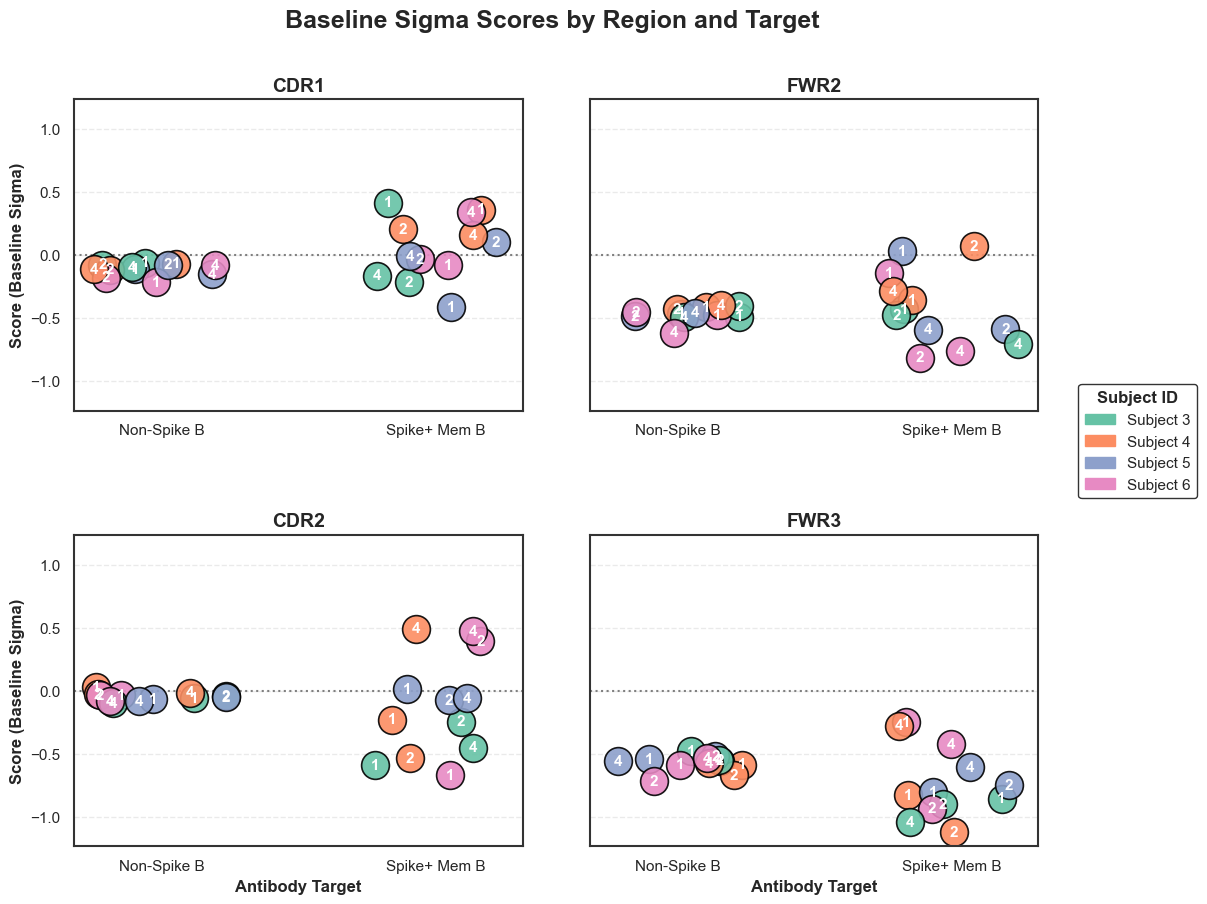

In [6]:
# 3. Data Preparation
df = df.dropna(subset=['baseline_sigma']).copy()
df['tp_label'] = df['time_point'].astype(str).str[0]

targets = sorted(df['ab_target'].dropna().unique())
target_mapping = {t: i for i, t in enumerate(targets)}
df['x_base'] = df['ab_target'].map(target_mapping)

np.random.seed(42) 
df['x_jitter'] = df['x_base'] + np.random.uniform(-0.25, 0.25, size=len(df))

subjects = sorted(df['subject_id'].dropna().unique())
palette = sns.color_palette("Set2", n_colors=len(subjects))
color_dict = dict(zip(subjects, palette))

max_val = df['baseline_sigma'].abs().max()
y_limit = max_val * 1.1

# Setting a cleaner base theme for better aesthetics
sns.set_theme(style="white")

# 4. Plotting
g = sns.FacetGrid(df, col="region", col_wrap=2, height=4.5, aspect=1.2, sharey=True)

def plot_custom_stripplot(data, **kwargs):
    ax = plt.gca()
    ax.axhline(0, color='gray', linestyle=':', zorder=1, linewidth=1.5)
    
    for _, row in data.iterrows():
        ax.scatter(row['x_jitter'], row['baseline_sigma'], 
                   color=color_dict[row['subject_id']], 
                   s=400, alpha=0.9, edgecolor='black', linewidth=1.2, zorder=2)
        
        ax.text(row['x_jitter'], row['baseline_sigma'], row['tp_label'], 
                ha='center', va='center', color='white', 
                fontsize=11, fontweight='bold', zorder=3)

g.map_dataframe(plot_custom_stripplot)

# IMPROVEMENT 1: Header without "region = "
g.set_titles(col_template="{col_name}", fontweight='bold', size=14)

# 5. Formatting
for ax in g.axes.flat:
    # IMPROVEMENT 2: X-labels and tick labels beneath EACH subplot
    ax.tick_params(labelbottom=True)
    
    ax.set_xticks(range(len(targets)))
    ax.set_xticklabels(targets, fontsize=11)
    ax.set_xlabel("Antibody Target", fontweight='bold', fontsize=12)
    ax.set_ylabel("Score (Baseline Sigma)", fontweight='bold', fontsize=12)
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#333333')
        spine.set_linewidth(1.5)
        
    ax.set_ylim(-y_limit, y_limit)

legend_patches = [mpatches.Patch(color=color_dict[sub], label=f'Subject {int(sub)}') for sub in subjects]

# IMPROVEMENT 3: Move legend closer to figure edges and style it
g.figure.legend(handles=legend_patches, title='Subject ID', title_fontproperties={'weight':'bold', 'size':12},
                loc='center left', bbox_to_anchor=(0.98, 0.5), frameon=True, edgecolor='black')

# Aesthetic improvements: adjusted padding (hspace/wspace) so text doesn't overlap
g.fig.subplots_adjust(right=0.95, top=0.88, hspace=0.4, wspace=0.15)  
g.fig.suptitle("Baseline Sigma Scores by Region and Target", fontsize=18, fontweight='bold')

# High quality export
if False:
    plt.savefig('final_updated_plot.png', bbox_inches='tight', dpi=300)
    plt.show()

In [13]:
# 1. Load the dataset
dataset = "cleaned_seqs_all_seq_no7-ab_target-time_point-all-[2026-05-31_10-57-48]_baseline_values.csv"
file_path = os.path.join("output","r_data",dataset)
metadata = "time_point"
df = pd.read_csv(file_path)

# Filtring out subject 7 if needed
if filt_7 == True:
    df = df[df.subject_id != 7]

# Drop missing values in the required columns
df = df.dropna(subset=['baseline_sigma', 'region', metadata, 'ab_target']).copy()
df['tp_label'] = df[metadata].astype(str).str[0]

# Calculate fixed baseline X positions based on the categories
targets = sorted(df['ab_target'].dropna().unique())
target_mapping = {t: i for i, t in enumerate(targets)}
df['x_base'] = df['ab_target'].map(target_mapping)

# Create the custom jitter to keep the arrangement identical to before
np.random.seed(42) 
df['x_jitter'] = df['x_base'] + np.random.uniform(-0.25, 0.25, size=len(df))

# --- COLOR MAPPING CHANGED TO TIME POINT ---
time_points = sorted(df[metadata].unique())
palette = sns.color_palette("Set1", n_colors=len(time_points))
color_dict = dict(zip(time_points, palette))

# Calculate absolute max for a symmetrical y-axis
max_val = df['baseline_sigma'].abs().max()
y_limit = max_val * 1.1

# Style configurations
sns.set_theme(style="white")

# Set up the 2x2 grid via FacetGrid
g = sns.FacetGrid(df, col="region", col_wrap=2, height=4.5, aspect=1.2, sharey=True)

# Custom plotting function to recreate the exact visual style from before
def plot_custom_stripplot(data, **kwargs):
    ax = plt.gca()
    ax.axhline(0, color='gray', linestyle=':', zorder=1, linewidth=1.5)
    
    for _, row in data.iterrows():
        # Large dots colored by time_point 
        ax.scatter(row['x_jitter'], row['baseline_sigma'], 
                   color=color_dict[row[metadata]], 
                   s=400, alpha=0.9, edgecolor='black', linewidth=1.2, zorder=2)
        
        # Inner white text restored
        ax.text(row['x_jitter'], row['baseline_sigma'], row['tp_label'], 
                ha='center', va='center', color='white', 
                fontsize=11, fontweight='bold', zorder=3)

# Map the function to the grid
g.map_dataframe(plot_custom_stripplot)

# 1. Simplified header
g.set_titles(col_template="{col_name}", fontweight='bold', size=14)

# Apply axes formatting
for ax in g.axes.flat:
    # X-labels beneath EACH subplot
    ax.tick_params(labelbottom=True)
    
    ax.set_xticks(range(len(targets)))
    ax.set_xticklabels(targets, fontsize=11)
    ax.set_xlabel("Antibody Target", fontweight='bold', fontsize=12)
    ax.set_ylabel("Score (Baseline Sigma)", fontweight='bold', fontsize=12)
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)
    
    # Enable all 4 border spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#333333')
        spine.set_linewidth(1.5)
        
    ax.set_ylim(-y_limit, y_limit)

# Create the Time Point Legend
legend_patches = [mpatches.Patch(color=color_dict[tp], label=f'{tp}') for tp in time_points]
g.figure.legend(handles=legend_patches, title=metadata, title_fontproperties={'weight':'bold', 'size':12},
                loc='center left', bbox_to_anchor=(0.98, 0.5), frameon=True, edgecolor='black')

# Final layout adjustments
g.fig.subplots_adjust(right=0.95, top=0.88, hspace=0.4, wspace=0.15)  
g.fig.suptitle("Baseline Sigma Scores by Region and Target", fontsize=18, fontweight='bold')

if False:
    plt.savefig('visually_exact_match_time_point.png', bbox_inches='tight', dpi=300)
    plt.show()

AttributeError: 'DataFrame' object has no attribute 'subject_id'